<a href="https://colab.research.google.com/github/PSriChandana/Data-Imputation/blob/main/Inferential_Stats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats

In [ ]:
cars_data=pd.read_csv('cars_sampled.csv')

In [ ]:
cars=cars_data.copy()

In [ ]:
cars=cars[(cars.yearOfRegistration <=2018)
        & (cars.yearOfRegistration>=1950)
        & (cars.price >=100)
        & (cars.price <=150000)
        & (cars.powerPS >=10)
        & (cars.powerPS <= 500)]


All hypotheses will be checked on the sample of data.


1Q. Three years back, the average price of a usedd car was 6000 $. Has
it changed now?

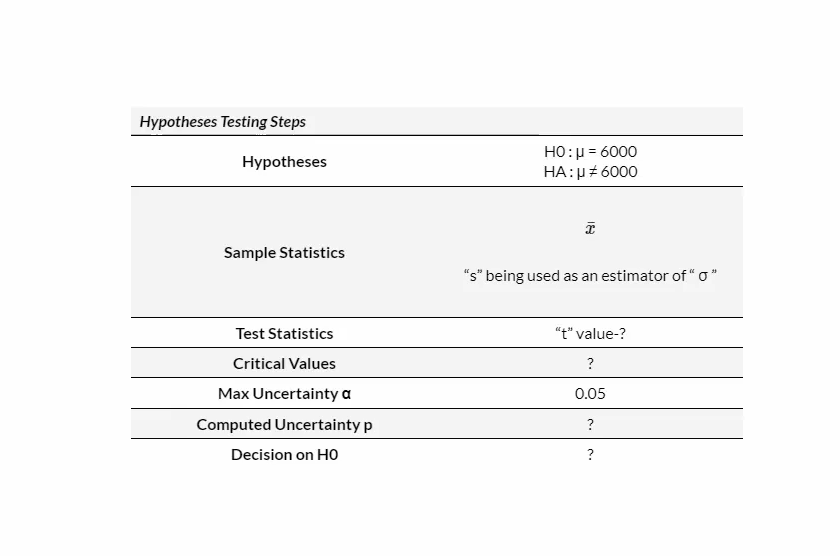


In [ ]:
sample_size=1000
sample1=cars.sample(sample_size,random_state=0)

In [ ]:
#postulated mean-hypothesized mean
pos_mean=6000
print(sample1['price'].mean())

6188.337


In [ ]:
from scipy.stats import ttest_1samp
statistic,pvalue=ttest_1samp(sample1['price'],pos_mean)
print(statistic,pvalue)

#pvalue is the uncertainity we calculated

0.8148683326967584 0.41534189398889065


Calculating the degreeof freedom

So we calculate the critical values so we set a significance value. The significance value is taken


In [ ]:
n=len(cars['price'])
#degree of freedom = n-1
df=n-1
print(n,df)
#this is the number of independent data

43155 43154


In [ ]:
#Significance Level
alpha=0.05

In [ ]:
#import scipy.stats and import ppf(point point function) to calculate the critical value
from scipy.stats import t
#Critical values from standard Distribution
cv = t.ppf([alpha/2,1-alpha/2],df)
#This is a two tail test, so this becomes the input to the ppf
print(cv)

[-1.96001896  1.96001896]


In [ ]:
#Because the teststatistics value lies betweent he critical values so we dont reject the null hyspothesis
#so we can conclude that the mean price is equal to 6000 $

Test for Proportionality

Q. Three years back, % of used car with automatic transmission were 23%. Has it changed now?
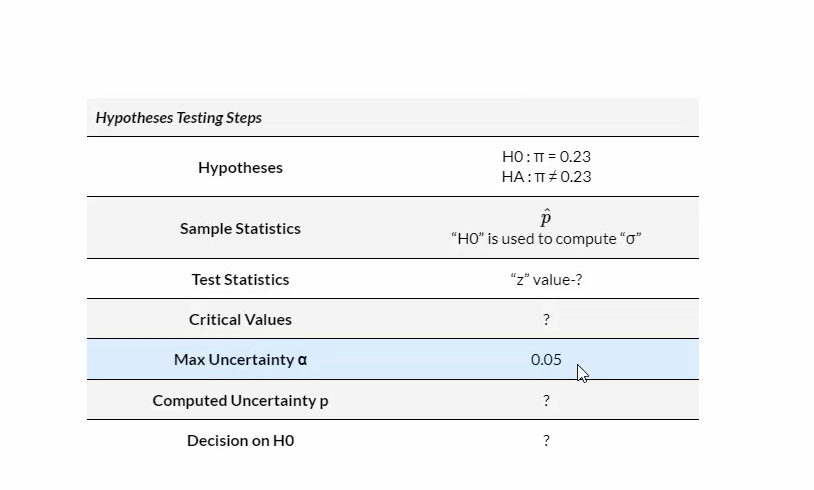

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
# No. of gearbox='automatic'
count = sample1['gearbox'].value